## How to use this notebook

- **Single-run cells**: The initial code cells run one simulation for the default and balanced segment-mix scenarios and are used by the Gantt / single-permit views.
- **Multi-run cells**: The later cells that call `run_multiple_simulations` repeat both scenarios many times and feed the aggregate statistics and box/whisker plots.
- **Workflow**: Run the single-run block first (to keep Gantt charts tied to one run), then run the multi-run block so the segment comparison plots reflect many simulations.

In [1]:
from run_simulation import run_simulation, print_statistics
import simpy

# Run the simulation
num_permits = 6410
print("Running simulation with " + str(num_permits) + " permits...")
# Scenario 1: Default segment allocation (~90% custom, 2% pre-approved, 8% self-cert, 80% like-for-like)
sim_default = run_simulation(
    num_permits=num_permits,
    random_seed=42,
    inter_arrival_time=0,
    sequential = "standard"
)
sim = sim_default  # for backward compatibility with other cells

# Get and display statistics
stats = sim_default.get_statistics()
print_statistics(stats)

Running simulation with 6410 permits...

SIMULATION STATISTICS

Total Completed Permits: 6410
Total In Progress: 0

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   : 4630 (72.23%)
  CUSTOM_NON_LIKE               : 1148 (17.91%)
  PRE_APPROVED_LIKE             :   93 ( 1.45%)
  PRE_APPROVED_NON_LIKE         :   21 ( 0.33%)
  SELF_CERT_LIKE                :  425 ( 6.63%)
  SELF_CERT_NON_LIKE            :   93 ( 1.45%)

--------------------------------------------------------------------------------
OVERALL PROCESSING TIME STATISTICS
--------------------------------------------------------------------------------
  Mean:     651.69 days
  Median:   577.56 days
  Std Dev:  327.20 days
  Min:      151.55 days
  Max:     4057.09 days

--------------------------------------------------------------------------------
PROCESSING TI

In [2]:
from run_simulation import run_multiple_simulations
import numpy as np

In [3]:
# Optional: Access individual permit data
print(f"\nFirst 5 completed permits:")
for permit in sim.completed_permits[:5]:
    total_time = permit.ready_for_construction - permit.created_at if permit.ready_for_construction else None
    print(f"  Permit {permit.permit_id} ({permit.segment.name}): "
          f"{total_time:.2f} days total, "
          f"{permit.public_works_rechecks} re-checks")



First 5 completed permits:
  Permit 214 (PRE_APPROVED_LIKE): 151.55 days total, 1 re-checks
  Permit 550 (CUSTOM_LIKE): 152.79 days total, 1 re-checks
  Permit 2362 (CUSTOM_LIKE): 157.20 days total, 1 re-checks
  Permit 2793 (CUSTOM_LIKE): 158.76 days total, 1 re-checks
  Permit 3573 (CUSTOM_LIKE): 159.28 days total, 1 re-checks


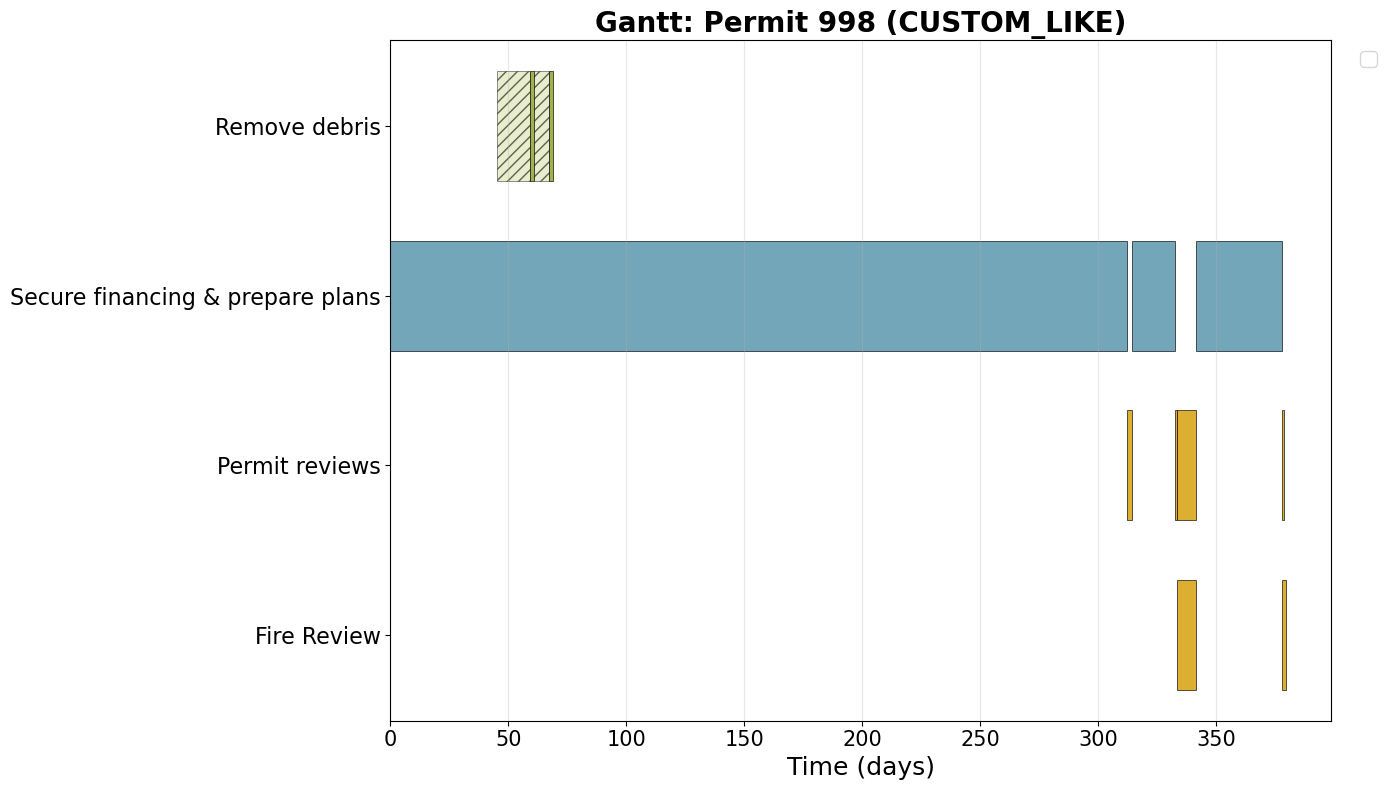

In [4]:
# Gantt chart for one random permit in segment 4 (CUSTOM_NON_LIKE)
# Parallel activities (e.g. Public Works, Fire Review, Public Health) appear on separate rows
from visualize_permits import plot_gantt_single_permit
import matplotlib.pyplot as plt

fig, ax = plot_gantt_single_permit(
    sim.completed_permits[1100],
    figsize=(14, 8), 
)
if fig:
    plt.show()

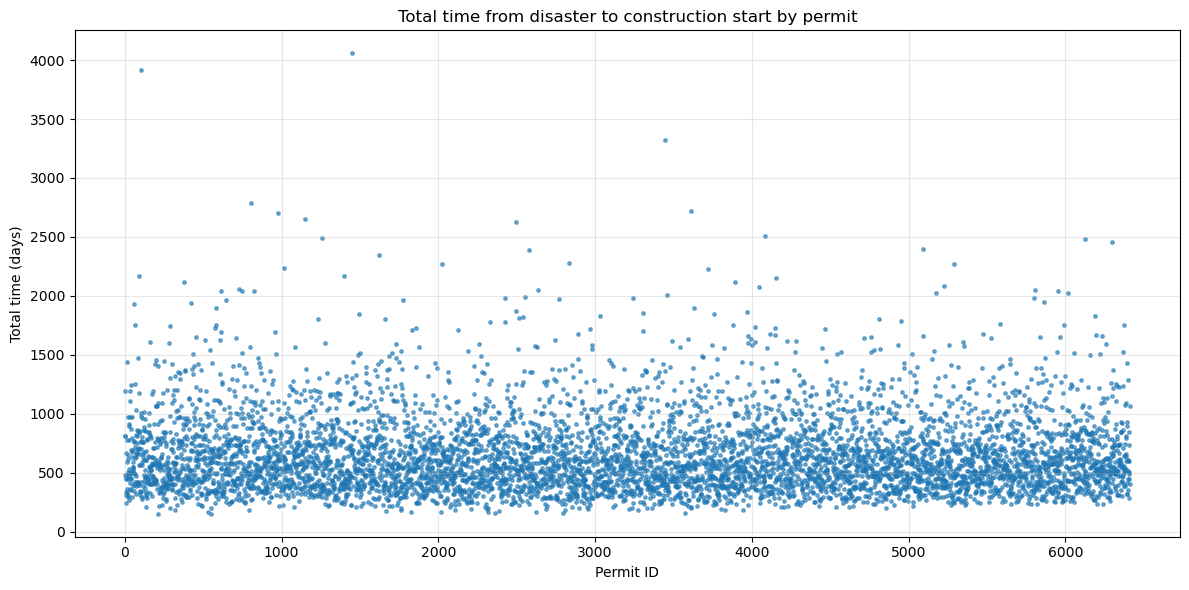

In [5]:
# Plot permit number (ID) vs total time to construction
import matplotlib.pyplot as plt

permit_ids = []
total_times = []

for p in sim.completed_permits:
    if p.ready_for_construction is not None and p.created_at is not None:
        permit_ids.append(p.permit_id)
        total_times.append(p.ready_for_construction - p.created_at)

plt.figure(figsize=(12, 6))
plt.scatter(permit_ids, total_times, s=6, alpha=0.6)
plt.xlabel("Permit ID")
plt.ylabel("Total time (days)")
plt.title("Total time from disaster to construction start by permit")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

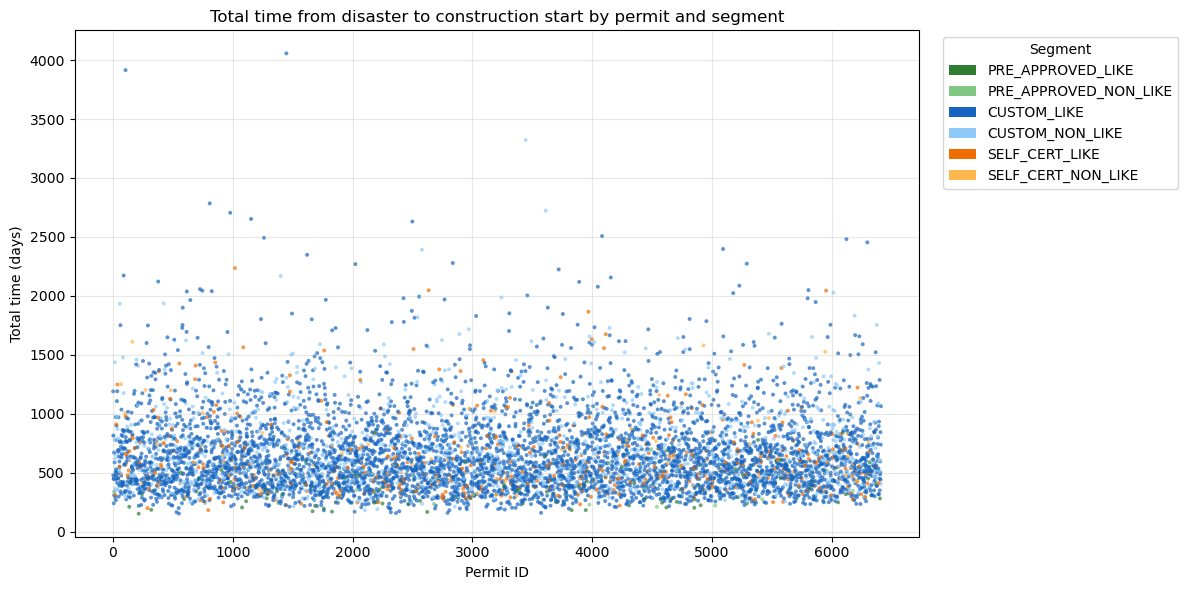

In [6]:
# Scatter plot: permit ID vs total time, colored by segment
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

permit_ids = []
total_times = []
segments = []

for p in sim.completed_permits:
    if p.ready_for_construction is None or p.created_at is None:
        continue
    permit_ids.append(p.permit_id)
    total_times.append(p.ready_for_construction - p.created_at)
    segments.append(p.segment)

# Define a color for each segment
from permit_simulation import Segment
segment_colors = {
    Segment.PRE_APPROVED_LIKE: "#2E7D32",      # green
    Segment.PRE_APPROVED_NON_LIKE: "#81C784",  # light green
    Segment.CUSTOM_LIKE: "#1565C0",            # blue
    Segment.CUSTOM_NON_LIKE: "#90CAF9",        # light blue
    Segment.SELF_CERT_LIKE: "#EF6C00",         # orange
    Segment.SELF_CERT_NON_LIKE: "#FFB74D",     # light orange,
}

colors = [segment_colors.get(seg, "#888888") for seg in segments]

plt.figure(figsize=(12, 6))
plt.scatter(permit_ids, total_times, c=colors, s=8, alpha=0.7, edgecolors="none")
plt.xlabel("Permit ID")
plt.ylabel("Total time (days)")
plt.title("Total time from disaster to construction start by permit and segment")
plt.grid(alpha=0.3)

# Legend
legend_patches = []
for seg, color in segment_colors.items():
    legend_patches.append(Patch(facecolor=color, edgecolor="none", label=seg.name))
plt.legend(handles=legend_patches, title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

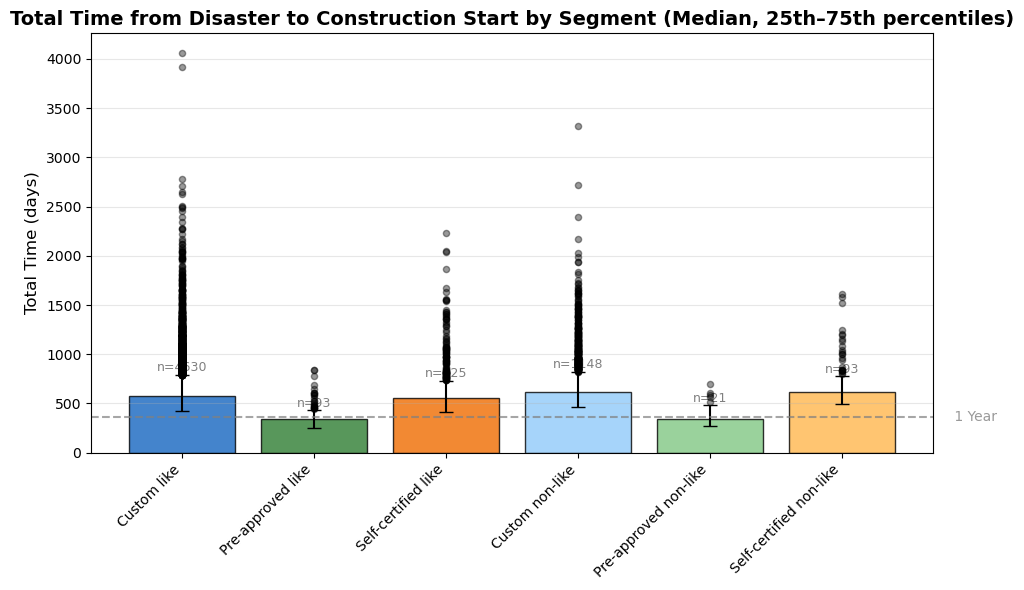

In [7]:
from visualize_permits import plot_total_time_by_segment_quartiles

fig, ax = plot_total_time_by_segment_quartiles(sim.completed_permits)
plt.show()

In [8]:
from run_simulation import run_simulation, print_statistics
import simpy

# Run the simulation
num_permits = 6410
print("Running simulation with " + str(num_permits) + " permits...")
# Scenario 2: Balanced segment allocation (50% pre-approved, 25% custom, 25% self-cert, 80% like-for-like)
sim_balanced = run_simulation(
    num_permits=num_permits,
    random_seed=42,
    inter_arrival_time=0,
    sequential = "standard",
    pct_pre_approved=0.5,
    pct_custom=0.25,
    pct_self_cert=0.25,
    pct_like_for_like=0.8
)

# Get and display statistics
stats = sim_balanced.get_statistics()
print_statistics(stats)

Running simulation with 6410 permits...

SIMULATION STATISTICS

Total Completed Permits: 6410
Total In Progress: 0

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   : 1307 (20.39%)
  CUSTOM_NON_LIKE               :  311 ( 4.85%)
  PRE_APPROVED_LIKE             : 2536 (39.56%)
  PRE_APPROVED_NON_LIKE         :  645 (10.06%)
  SELF_CERT_LIKE                : 1305 (20.36%)
  SELF_CERT_NON_LIKE            :  306 ( 4.77%)

--------------------------------------------------------------------------------
OVERALL PROCESSING TIME STATISTICS
--------------------------------------------------------------------------------
  Mean:     514.40 days
  Median:   436.29 days
  Std Dev:  296.91 days
  Min:       96.80 days
  Max:     2772.48 days

--------------------------------------------------------------------------------
PROCESSING TI

In [9]:
# Run multiple simulations for both segment-mix scenarios to see aggregate behavior
n_runs = 10

scenario_params_list = [
    {
        "name": "Default",
        "sequential": "standard",
    },
    {
        "name": "Balanced",
        "sequential": "standard",
        "pct_pre_approved": 0.5,
        "pct_custom": 0.25,
        "pct_self_cert": 0.25,
        "pct_like_for_like": 0.8,
    },
]

multi_results = run_multiple_simulations(
    n_runs=n_runs,
    num_permits=num_permits,
    simulation_duration=None,
    base_seed=42,
    inter_arrival_time=0.0,
    scenario_params_list=scenario_params_list,
    collect_permits=True,
)

all_default_permits: list = []
all_balanced_permits: list = []

for res in multi_results:
    scenario = res["scenario"]
    permits = res.get("permits", [])
    if scenario == "Default":
        all_default_permits.extend(permits)
    elif scenario == "Balanced":
        all_balanced_permits.extend(permits)


def _print_summary(name: str, permits: list) -> None:
    if not permits:
        print(f"{name}: no completed permits across runs")
        return
    total_times = np.array(
        [
            p.ready_for_construction - p.created_at
            for p in permits
            if getattr(p, "ready_for_construction", None) is not None
        ]
    )
    if total_times.size == 0:
        print(f"{name}: no permits with ready_for_construction timestamps")
        return

    print(
        f"{name}: n={len(total_times)}, mean={total_times.mean():.2f}, "
        f"median={np.median(total_times):.2f}"
    )


print(f"Ran {n_runs} runs per segment-mix scenario. Aggregate total-time stats:")
_print_summary("Default", all_default_permits)
_print_summary("Balanced", all_balanced_permits)

Ran 10 runs per segment-mix scenario. Aggregate total-time stats:
Default: n=64100, mean=653.16, median=578.85
Balanced: n=64100, mean=514.60, median=435.30


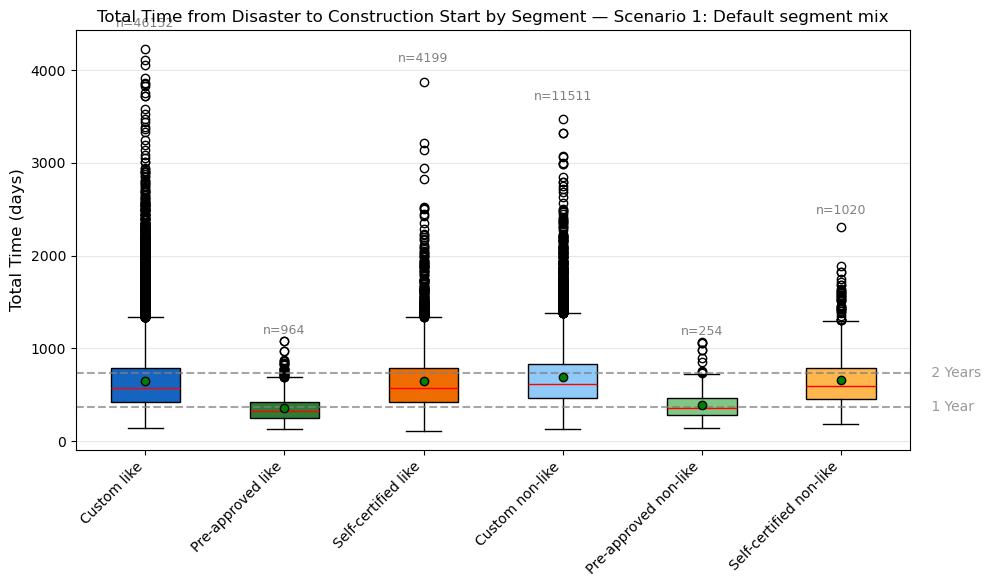

In [10]:
from visualize_permits import plot_total_time_by_segment
import matplotlib.pyplot as plt

# Box-and-whisker: Scenario 1 — Default segment allocation (aggregate across runs)
fig, ax = plot_total_time_by_segment(all_default_permits, figsize=(10, 6), show_boxplot=True)
if ax is not None:
    ax.set_title("Total Time from Disaster to Construction Start by Segment — Scenario 1: Default segment mix", fontsize=12)
plt.show()

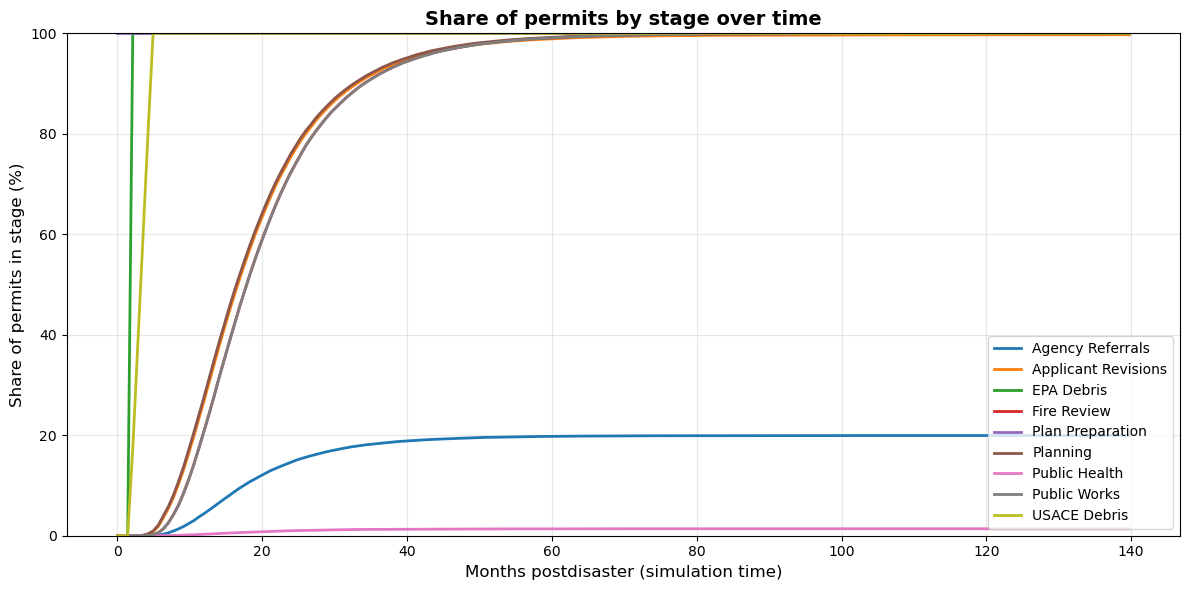

In [11]:
from visualize_permits import plot_permits_by_stage_over_time
import matplotlib.pyplot as plt
fig, ax = plot_permits_by_stage_over_time(all_default_permits)
plt.show()

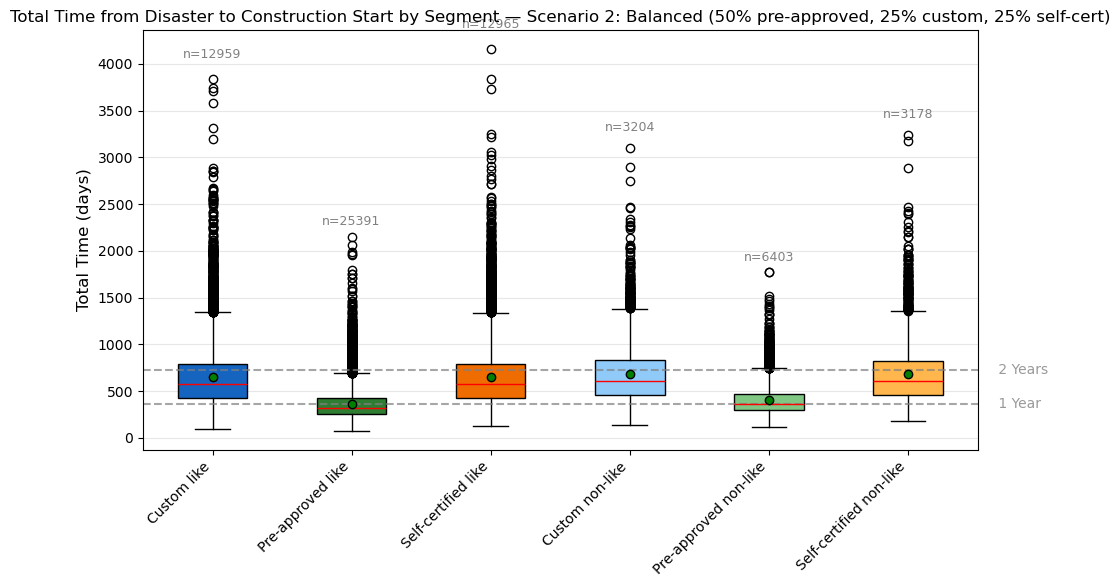

In [12]:
# Box-and-whisker: Scenario 2 — Balanced segment allocation (50% pre-approved, 25% custom, 25% self-cert, 80% like-for-like, aggregate across runs)
fig, ax = plot_total_time_by_segment(all_balanced_permits, figsize=(10, 6), show_boxplot=True)
if ax is not None:
    ax.set_title("Total Time from Disaster to Construction Start by Segment — Scenario 2: Balanced (50% pre-approved, 25% custom, 25% self-cert)", fontsize=12)
plt.show()

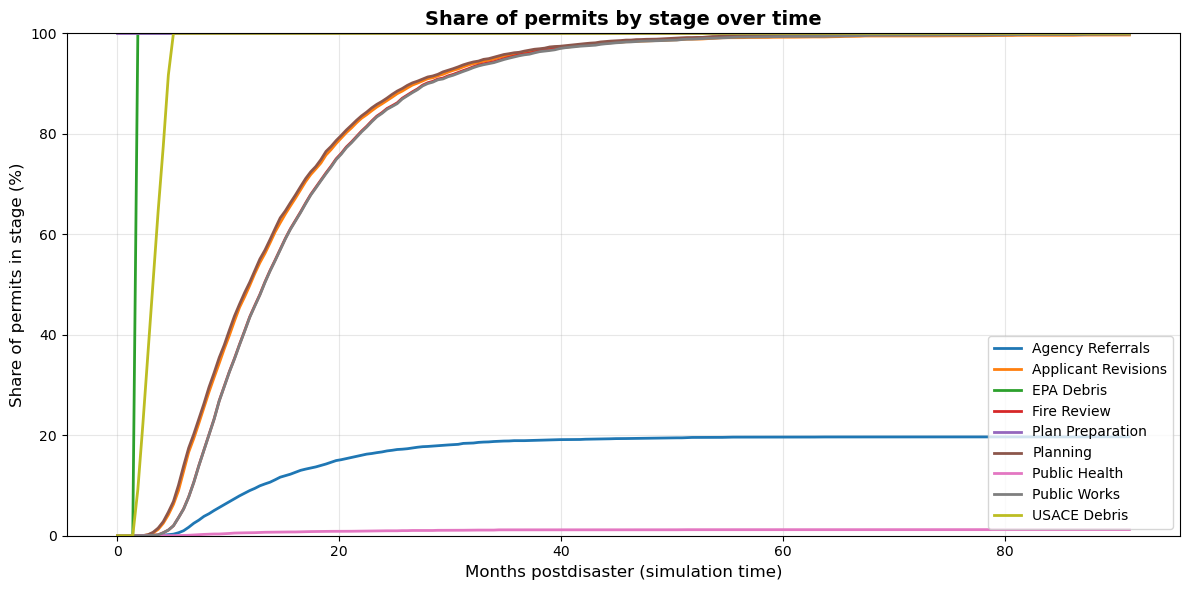

In [13]:
from visualize_permits import plot_permits_by_stage_over_time
import matplotlib.pyplot as plt
fig, ax = plot_permits_by_stage_over_time(sim_balanced.completed_permits)
plt.show()